## TDA Pitch Clustering

In [ ]:
from pathlib import Path

ROOT_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MODELS_DIR = ROOT_DIR / 'models'
DATA_DIR = ROOT_DIR / 'data'
RESULTS_DIR = ROOT_DIR / 'results'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pybaseball
pybaseball.cache.enable()

In [ ]:
import sys

sys.path.insert(0, str(ROOT_DIR / 'src' / 'tda'))
from tda_classifier import fetch_savant_csv

# get all available data
# NOTE: switched from pybaseball.statcast() to the direct Baseball Savant CSV
# export -- pybaseball.statcast()'s postprocessing crashes in some environments
# (duplicate-column bug, see docs/METHODOLOGY_REVIEW.md item 7's side finding).
# This full-season (~8 month) pull is unverified at this scale; check
# tda_classifier.fetch_savant_csv's `timeout=60` if this cell times out or
# returns truncated data.
df = fetch_savant_csv('2025-03-28', '2025-11-04')

In [4]:
df.columns.to_list()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [5]:
df['pitch_type'].unique()

array(['FS', 'CU', 'FC', 'FF', 'CH', 'KC', 'SL', 'ST', 'SI', None, 'SV',
       'CS', 'KN', 'PO', 'FA', 'UN', 'EP', 'SC', 'FO'], dtype=object)

In [6]:
stuffCols = [
    'pitcher',       # Pitcher name
    'pitch_type',    # Pitch type
    'p_throws',      # Pitcher throws (L/R)
    'release_speed',  # Pitch speed
    'pfx_x',          # Horizontal break
    'pfx_z',          # Induced vertical break
    'release_spin_rate', # Spin rate
    'spin_axis',      # Spin axis
    'release_extension', # Release extension
    'release_pos_x',  # Release position X
    'release_pos_z'   # Release position Z
]

In [7]:
stuffDF = df[stuffCols]

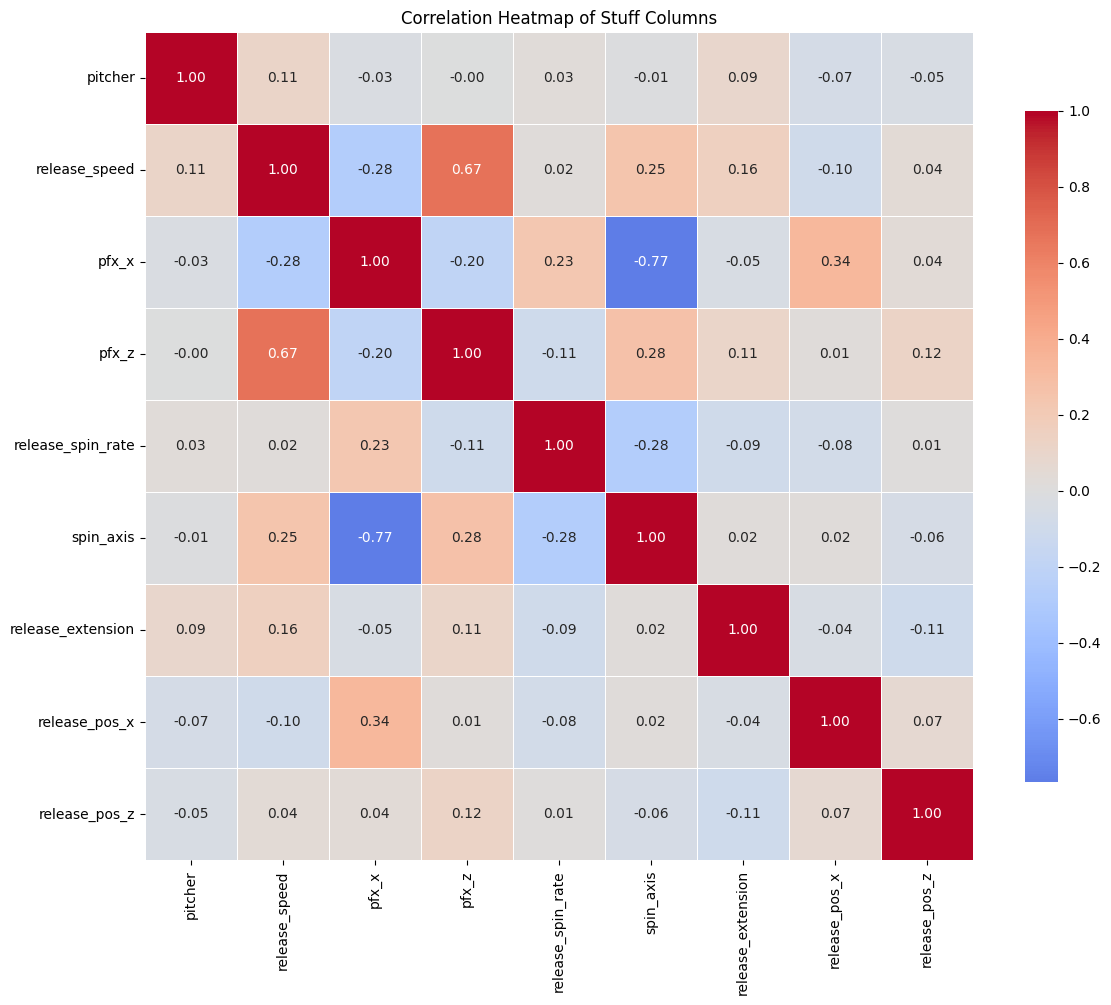

In [8]:
# Check correlation between stuff columns
corr = stuffDF.corr(numeric_only=True)

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Stuff Columns")
plt.tight_layout()
plt.show()

In [ ]:
# Mirror movement and position
stuffDF.loc[stuffDF['p_throws'] == 'L', ['pfx_x', 'release_pos_x']] *= -1

# Mirror spin axis to match RHP frame
stuffDF.loc[stuffDF['p_throws'] == 'L', 'spin_axis'] = (
    360 - stuffDF.loc[stuffDF['p_throws'] == 'L', 'spin_axis']
) % 360

# spin_axis is circular (359deg and 1deg are nearly identical directions) --
# encode as (cos, sin) instead of feeding the raw degree value into Euclidean
# distance downstream. See docs/METHODOLOGY_REVIEW.md item 2.
spin_rad = np.deg2rad(stuffDF['spin_axis'])
stuffDF['spin_cos'] = np.cos(spin_rad)
stuffDF['spin_sin'] = np.sin(spin_rad)

In [ ]:
# Only the columns actually used for clustering -- averaging spin_cos/spin_sin
# per (pitcher, pitch_type) is also the mathematically correct way to average
# a circular quantity, unlike a naive arithmetic mean of raw degrees.
FEATURE_COLS = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate',
                'spin_cos', 'spin_sin', 'release_extension',
                'release_pos_x', 'release_pos_z']

avgStuff = stuffDF.groupby(['pitcher', 'pitch_type'])[FEATURE_COLS].mean()
avgStuff = avgStuff.dropna()

In [11]:
avgStuff

release_speed     pfx_x     pfx_z  release_spin_rate  \
pitcher pitch_type                                                         
434378  CH              84.678829     -1.08  0.780766        1728.887387   
        CU              78.470079  0.628504 -1.027428        2748.244094   
        FF               93.92132  -0.73945  1.552868        2434.958545   
        SI                  93.27    -0.993     1.362             2474.0   
        SL               87.12883  0.337743  0.459934        2503.444811   
...                           ...       ...       ...                ...   
829272  FF              91.089272 -0.582874  1.360575        2202.819923   
        KC              72.334109  0.594109 -1.654961        2731.852713   
        SI              90.366667 -1.273333  1.061667        2171.666667   
        SL                81.6248      0.21   0.25624            2381.12   
        ST              76.533333  1.053333 -0.886667        2746.666667   

                     spin_axis  release_extension  release_pos_x  \
pitcher pitch_type                                                 
434378  CH           228.72973           6.041441      -2.018829   
        CU           39.325459           5.996063      -1.973438   
        FF          206.906937           6.012606      -1.688376   
        SI               195.6               6.03         -1.614   
        SL          167.462932           6.019275        -1.8714   
...                        ...                ...            ...   
829272  FF          215.827586           6.261303      -1.626552   
        KC           16.263566           6.064341      -1.255271   
        SI          224.333333           6.266667           -1.7   
        SL             148.704             6.1584       -1.71928   
        ST           39.333333           5.933333           -1.8   

                    release_pos_z  spin_axis_clock  
pitcher pitch_type                                  
434378  CH                7.04973          8.77027  
        CU               7.099948         2.149606  
        FF               7.147462         7.998308  
        SI                  7.131              7.5  
        SL               7.070824         6.570016  
...                           ...              ...  
829272  FF               5.628582          8.02682  
        KC               5.881163         1.689922  
        SI               5.616667         8.333333  
        SL                5.64208            5.856  
        ST               5.596667              2.0  

[3935 rows x 9 columns]

In [12]:
import itertools
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import kmapper as km

# Prepare data
X = avgStuff.dropna().values
X_scaled = StandardScaler().fit_transform(X)
mapper = km.KeplerMapper()

# Define more granular parameter grids
n_cubes_list = list(range(4, 13))  # 4 to 12 inclusive
perc_overlap_list = np.arange(0.2, 0.81, 0.1)  # 0.2, 0.3, ..., 0.8
eps_list = np.arange(0.4, 2.05, 0.2)  # 0.4, 0.6, ..., 2.0
min_samples_list = list(range(2, 21, 2))  # 2, 4, ..., 20

results = []
for n_cubes, perc_overlap, eps, min_samples in itertools.product(
    n_cubes_list, perc_overlap_list, eps_list, min_samples_list
):
    lens = mapper.fit_transform(X_scaled, projection=PCA(n_components=2))
    graph = mapper.map(
        lens,
        X_scaled,
        clusterer=DBSCAN(eps=eps, min_samples=min_samples),
        cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap)
    )
    node_sizes = [len(graph['nodes'][n]) for n in graph['nodes']]
    results.append({
        'n_cubes': n_cubes,
        'perc_overlap': perc_overlap,
        'eps': eps,
        'min_samples': min_samples,
        'nodes': len(graph['nodes']),
        'edges': len(graph['links']),
        'median_node_size': np.median(node_sizes) if node_sizes else 0,
        'max_node_size': np.max(node_sizes) if node_sizes else 0
    })

# Convert results to DataFrame for easy inspection
results_df = pd.DataFrame(results)

In [13]:
results_df.sort_values(by='median_node_size', ascending=False)  # or any other metric you care about
results_df['node_edge_diff'] = results_df['nodes'] - results_df['edges']

In [14]:
# Filter results_df to only include trials with nodes between 50 and 100
filtered_results = results_df[(results_df['nodes'] >= 16) &
                              (results_df['nodes'] < 100) &
                              (results_df['median_node_size'] >= 10)]

In [15]:
filtered_results.sort_values(by='node_edge_diff', ascending=False)

,n_cubes,perc_overlap,eps,min_samples,nodes,edges,median_node_size,max_node_size,node_edge_diff
5090,12,0.2,1.4,2,91,68,11.0,913,23
3162,9,0.2,0.6,6,26,9,10.0,190,17
5100,12,0.2,1.6,2,82,67,17.0,918,15
2551,8,0.2,1.0,4,39,26,15.0,1380,13
1950,7,0.2,1.6,2,49,36,13.0,1600,13
...,...,...,...,...,...,...,...,...,...
2929,8,0.6,1.2,20,31,30,561.0,2085,1
2928,8,0.6,1.2,18,31,30,563.0,2094,1
2927,8,0.6,1.2,16,31,30,572.0,2106,1
2926,8,0.6,1.2,14,32,31,565.5,2129,1


In [ ]:
n_cubes = 10
perc_overlap = 0.3
eps = 1
min_samples = 4

# ponytail: reusing the previously grid-searched hyperparameters above rather
# than re-running the full grid search against the corrected 9-feature space
# (spin_cos/spin_sin in place of spin_axis_clock). The fix is about feature
# correctness, not hyperparameter optimality. Upgrade path: re-run the grid
# search cell above against the corrected avgStuff if the resulting graph's
# node count/shape looks off.

In [ ]:
import kmapper as km
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Prepare data -- ONE scaler, fit once on the full feature set, used for both
# the fit below and the saved model (no separate refit-on-a-subset later,
# which was the source of the fit/inference feature-space mismatch --
# see docs/METHODOLOGY_REVIEW.md item 1).
X = avgStuff.values
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
mapper = km.KeplerMapper()

# Use PCA as lens/filter
lens = mapper.fit_transform(X_scaled, projection=PCA(n_components=2))

# Create the Mapper graph
graph = mapper.map(
    lens,
    X_scaled,
    clusterer=DBSCAN(eps=eps, min_samples=min_samples),
    cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap)
)

# Assuming avgStuff has a pitch_type column and you have the indices for each node
import collections

# Prepare color values: map each row to a pitch type index
pitch_type_labels = avgStuff.index.get_level_values('pitch_type').to_list()
unique_types = list(set(pitch_type_labels))
type_to_int = {t: i for i, t in enumerate(unique_types)}
color_values = [type_to_int[t] for t in pitch_type_labels]

for node, indices in graph['nodes'].items():
    types_in_node = [pitch_type_labels[i] for i in indices]
    most_common = collections.Counter(types_in_node).most_common(1)[0]

# Visualize with color
mapper_html_path = RESULTS_DIR / "mapper_pitch_types_colored.html"
mapper.visualize(
    graph,
    color_values=color_values,
    color_function_name="Pitch Type",
    path_html=str(mapper_html_path),
    title="Mapper: Pitch Types (Colored by Type)"
)

node_summary = []
stuff_columns = avgStuff.columns  # These are your "stuff" features

for node, indices in graph['nodes'].items():
    types_in_node = [pitch_type_labels[i] for i in indices]
    most_common = collections.Counter(types_in_node).most_common(1)[0]
    # Get the average "stuff" for this cluster
    avg_stuff_in_node = np.mean(X[indices], axis=0)  # X is your unscaled avgStuff values
    avg_stuff_dict = {col: avg_stuff_in_node[i] for i, col in enumerate(stuff_columns)}
    node_summary.append({
        'node': node,
        'size': len(indices),
        'most_common_pitch_type': most_common[0],
        'count': most_common[1],
        'unique_types': len(set(types_in_node)),
        **avg_stuff_dict  # Unpack the average stuff values into the summary
    })

import os
os.system(f"open -a 'Google Chrome' {mapper_html_path}")

In [ ]:
# Create a DataFrame summarizing each cluster (node)
cluster_summary_df = pd.DataFrame(node_summary)
cluster_summary_df = cluster_summary_df.rename(columns={'node': 'cluster'})

cols_to_keep = ['cluster', 'size', 'most_common_pitch_type', 'count', 'unique_types'] + list(FEATURE_COLS)
cluster_summary_df = cluster_summary_df[cols_to_keep]

# Adjust pfx_x and pfx_z values
cluster_summary_df['pfx_x'] = cluster_summary_df['pfx_x'] * -12
cluster_summary_df['pfx_z'] = cluster_summary_df['pfx_z'] * 12

# Rename columns
cluster_summary_df = cluster_summary_df.rename(columns={'pfx_x': 'HB', 'pfx_z': 'IVB'})

# Display-only recovered spin_axis (correct circular mean, for human-readable
# output only -- clustering itself uses spin_cos/spin_sin directly).
cluster_summary_df['spin_axis'] = np.degrees(
    np.arctan2(cluster_summary_df['spin_sin'], cluster_summary_df['spin_cos'])
) % 360

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(cluster_summary_df.sort_values(by='release_speed', ascending=False))

In [ ]:
import pickle

# Save the fitted components for later use -- the SAME scaler/pca/feature set
# used for the actual fit above, not a separate refit on a subset of columns.
model_components = {
    'scaler': scaler,
    'pca': PCA(n_components=2).fit(X_scaled),
    'mapper': mapper,
    'graph': graph,
    'cluster_summary': cluster_summary_df,
    'original_data': avgStuff,
    'stuff_columns': list(FEATURE_COLS),
}

# Save to file
tda_model_path = MODELS_DIR / 'tda_mapper_model.pkl'
with open(tda_model_path, 'wb') as f:
    pickle.dump(model_components, f)

print(f"Model components saved to '{tda_model_path}'")

In [20]:
def classify_new_pitches(new_pitch_data, model_components):
    """
    Classify new pitch data into existing TDA clusters.
    
    Parameters:
    -----------
    new_pitch_data : DataFrame or array
        New pitch data with columns matching the stuff columns
    model_components : dict
        Dictionary containing the fitted scaler and cluster summary
    
    Returns:
    --------
    DataFrame with cluster assignments and distances to cluster centroid
    """
    scaler = model_components['scaler']
    cluster_summary = model_components['cluster_summary']
    stuff_columns = model_components['stuff_columns']
    
    # Remove spin_axis_clock if it's in stuff_columns (it's derived, not raw data)
    input_columns = [col for col in stuff_columns if col != 'spin_axis_clock']
    
    # Handle input
    if isinstance(new_pitch_data, pd.DataFrame):
        X_new = new_pitch_data[input_columns].values
    else:
        X_new = new_pitch_data
    
    # Apply scaling
    X_new_scaled = scaler.transform(X_new)
    
    # Extract cluster centroids from cluster_summary (in original space)
    # Map cluster features back to original space for scaling
    # Since HB = pfx_x * -12 and IVB = pfx_z * 12, reverse the transformation
    cluster_summary_original = cluster_summary.copy()
    cluster_summary_original['pfx_x'] = cluster_summary_original['HB'] / -12
    cluster_summary_original['pfx_z'] = cluster_summary_original['IVB'] / 12
    
    # Use the same input columns (without spin_axis_clock)
    input_columns = [col for col in stuff_columns if col != 'spin_axis_clock']
    X_clusters = cluster_summary_original[input_columns].values
    X_clusters_scaled = scaler.transform(X_clusters)
    
    classifications = []
    
    for i, pitch_scaled in enumerate(X_new_scaled):
        # Find closest cluster centroid
        distances = np.linalg.norm(X_clusters_scaled - pitch_scaled, axis=1)
        closest_cluster_idx = np.argmin(distances)
        
        # Get cluster info
        closest_cluster = cluster_summary.iloc[closest_cluster_idx]
        
        classifications.append({
            'pitch_index': i,
            'cluster_id': closest_cluster['cluster'],  # Get the actual mapper node name (e.g., 'cube1_cluster0')
            'cluster_idx': closest_cluster_idx,  # Also include the numeric index for reference
            'distance_to_cluster': float(distances[closest_cluster_idx]),
            'cluster_size': int(closest_cluster['size']),
            'dominant_pitch_type': closest_cluster['most_common_pitch_type'],
            'cluster_release_speed': float(closest_cluster['release_speed'])
        })
    
    return pd.DataFrame(classifications)

# Test with a sample pitch (use a different index to test)
test_pitch = avgStuff.iloc[5:6]  # Use different pitch to see real classification
result = classify_new_pitches(test_pitch, model_components)
print("Classification result:")
print(result)

Classification result:
   pitch_index       cluster_id  cluster_idx  distance_to_cluster  \
0            0  cube15_cluster0            9             2.061324   

   cluster_size dominant_pitch_type  cluster_release_speed  
0            23                  CU              82.921033  


In [ ]:
# Test classification on a new day of data
print("Querying pitches from a single day...")
new_df = fetch_savant_csv('2025-09-15', '2025-09-15')
print(f"Found {len(new_df)} pitches on 2025-09-15")

# Prepare the data the same way as the original
new_stuffDF = new_df[stuffCols].copy()

# Mirror movement and position for LHP
new_stuffDF.loc[new_stuffDF['p_throws'] == 'L', ['pfx_x', 'release_pos_x']] *= -1

# Mirror spin axis to match RHP frame
new_stuffDF.loc[new_stuffDF['p_throws'] == 'L', 'spin_axis'] = (
    360 - new_stuffDF.loc[new_stuffDF['p_throws'] == 'L', 'spin_axis']
) % 360

# Calculate average by pitcher and pitch type
new_avgStuff = new_stuffDF.groupby(['pitcher', 'pitch_type']).mean(numeric_only=True)
new_avgStuff = new_avgStuff.dropna()

print(f"\nFound {len(new_avgStuff)} pitcher-pitch combinations")
print(f"\nClassifying {len(new_avgStuff)} pitches into clusters...")

# Classify new pitches
classifications = classify_new_pitches(new_avgStuff, model_components)

# Display results sorted by cluster
result_summary = classifications.sort_values('cluster_id')
print("\nClassification Results:")
print(result_summary.to_string())

# Show cluster distribution
print("\nPitches by Cluster:")
print(classifications['cluster_id'].value_counts())